# Lab 10 Retraining and Deployment Notebook

This notebook rebuilds the Lab 10 classifier package for Raspberry Pi deployment. It reproduces the current Lab 8/9 baseline, trains a stronger GPU-backed classifier with augmentation, evaluates per-class behavior, and prepares the deployment package used by `scripts/inference_app.py`.

In [11]:

from pathlib import Path
import random
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision.datasets import ImageFolder
from torchvision.models import MobileNet_V3_Small_Weights, mobilenet_v3_small

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

if not torch.cuda.is_available():
    raise RuntimeError('CUDA GPU is required for this Lab 10 retraining notebook. Install a CUDA-enabled PyTorch build or run on the GPU machine.')

DEVICE = torch.device('cuda')
print('Using GPU:', torch.cuda.get_device_name(0))


Using GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [12]:

WORKSPACE_ROOT = Path.cwd()
if WORKSPACE_ROOT.name == 'notebook':
    LAB10_ROOT = WORKSPACE_ROOT.parent
else:
    LAB10_ROOT = Path('ml-perception-labs/lab10_rpi_deployment').resolve()
LABS_ROOT = LAB10_ROOT.parent
LAB8_ROOT = LABS_ROOT / 'lab08_finetuning'
DATASET_ROOT = LAB8_ROOT / 'data' / 'raw'

DEPLOYMENT_DIR = LAB10_ROOT / 'deployment_package'
FIGURES_DIR = LAB10_ROOT / 'outputs' / 'figures'
TABLES_DIR = LAB10_ROOT / 'outputs' / 'tables'
LOGS_DIR = LAB10_ROOT / 'outputs' / 'logs'
for directory in [DEPLOYMENT_DIR, FIGURES_DIR, TABLES_DIR, LOGS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

CLASS_ORDER = ['Noodles', 'Rice', 'bottled water', 'canned goods', 'combo']
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 18
PATIENCE = 5
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

print('Lab 10 root:', LAB10_ROOT)
print('Dataset root:', DATASET_ROOT)


Lab 10 root: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab10_rpi_deployment
Dataset root: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab08_finetuning\data\raw


## Dataset and Splits

The split follows the Lab 8 seed and 60/20/20 train/validation/test strategy so the baseline remains comparable.

In [13]:

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.72, 1.0), ratio=(0.85, 1.15)),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.15, hue=0.03)], p=0.85),
    transforms.RandomRotation(degrees=12),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.35),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.20),
    transforms.RandomAutocontrast(p=0.25),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
    transforms.RandomErasing(p=0.18, scale=(0.02, 0.10), ratio=(0.3, 3.3), value='random'),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

base_dataset = ImageFolder(DATASET_ROOT, transform=eval_transform)
if base_dataset.classes != CLASS_ORDER:
    raise RuntimeError(f'Class order mismatch. Expected {CLASS_ORDER}, got {base_dataset.classes}')

indices = torch.randperm(len(base_dataset), generator=torch.Generator().manual_seed(SEED)).tolist()
n_train = int(0.60 * len(indices))
n_val = int(0.20 * len(indices))
TRAIN_INDICES = indices[:n_train]
VAL_INDICES = indices[n_train:n_train+n_val]
TEST_INDICES = indices[n_train+n_val:]

train_dataset = ImageFolder(DATASET_ROOT, transform=train_transform)
eval_dataset = ImageFolder(DATASET_ROOT, transform=eval_transform)
train_targets = [base_dataset.targets[i] for i in TRAIN_INDICES]
class_counts = np.bincount(train_targets, minlength=len(CLASS_ORDER))
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = [class_weights[base_dataset.targets[i]] for i in TRAIN_INDICES]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(Subset(train_dataset, TRAIN_INDICES), batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(Subset(eval_dataset, VAL_INDICES), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(Subset(eval_dataset, TEST_INDICES), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

pd.DataFrame({'class': CLASS_ORDER, 'train_count': class_counts})


,class,train_count
0,Noodles,71
1,Rice,56
2,bottled water,55
3,canned goods,57
4,combo,61


## Baseline Metrics

The current Lab 8/9 MobileNetV2 TFLite model is the baseline to beat. It reached 72% held-out test accuracy, with canned goods as the strongest class and bottled water/combo as the most important weak area.

In [14]:

baseline_summary = {
    'model': 'MobileNetV2_m1_t3 TFLite baseline',
    'input_size': 64,
    'test_accuracy': 0.72,
    'macro_f1': 0.7269,
    'weak_classes': 'bottled water and combo',
    'best_class': 'canned goods',
}
pd.DataFrame([baseline_summary]).to_csv(TABLES_DIR / 'baseline_summary.csv', index=False)
pd.DataFrame([baseline_summary])


,model,input_size,test_accuracy,macro_f1,weak_classes,best_class
0,MobileNetV2_m1_t3 TFLite baseline,64,0.72,0.7269,bottled water and combo,canned goods


## GPU Model Training

MobileNetV3-small is compact enough for Raspberry Pi CPU inference but stronger than the previous 64x64 baseline. This section trains on CUDA with mixed precision and selects the checkpoint by validation macro F1 plus worst-class recall.

In [15]:

def build_model(num_classes: int) -> nn.Module:
    weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1
    model = mobilenet_v3_small(weights=weights)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model

model = build_model(len(CLASS_ORDER)).to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.08)
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = GradScaler('cuda')
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))


Trainable parameters: 1522981


In [16]:

def run_epoch(loader, training: bool):
    model.train(training)
    total_loss = 0.0
    all_labels, all_preds = [], []
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with torch.set_grad_enabled(training):
            with autocast('cuda'):
                logits = model(images)
                loss = criterion(logits, labels)
            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
        total_loss += float(loss.item()) * images.size(0)
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy().tolist())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    recalls = recall_score(all_labels, all_preds, average=None, labels=list(range(len(CLASS_ORDER))), zero_division=0)
    return avg_loss, acc, macro_f1, float(np.min(recalls))

best_score = -1.0
best_path = DEPLOYMENT_DIR / 'lab10_mobilenetv3_small_best.pth'
history = []
patience_left = PATIENCE

for epoch in range(1, EPOCHS + 1):
    start = time.perf_counter()
    train_loss, train_acc, train_f1, train_worst_recall = run_epoch(train_loader, training=True)
    val_loss, val_acc, val_f1, val_worst_recall = run_epoch(val_loader, training=False)
    scheduler.step()
    score = 0.70 * val_f1 + 0.30 * val_worst_recall
    row = {
        'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc, 'train_macro_f1': train_f1,
        'val_loss': val_loss, 'val_acc': val_acc, 'val_macro_f1': val_f1, 'val_worst_recall': val_worst_recall,
        'selection_score': score, 'seconds': time.perf_counter() - start,
    }
    history.append(row)
    print(row)
    if score > best_score:
        best_score = score
        torch.save(model.state_dict(), best_path)
        patience_left = PATIENCE
    else:
        patience_left -= 1
        if patience_left <= 0:
            print('Early stopping triggered.')
            break

history_df = pd.DataFrame(history)
history_df.to_csv(TABLES_DIR / 'lab10_training_history.csv', index=False)
history_df.tail()


{'epoch': 1, 'train_loss': 1.5989492273330688, 'train_acc': 0.2866666666666667, 'train_macro_f1': 0.2855578579586865, 'val_loss': 1.3471447181701661, 'val_acc': 0.48, 'val_macro_f1': 0.46026645768025076, 'val_worst_recall': 0.2222222222222222, 'selection_score': 0.38885318704284216, 'seconds': 3.744199699998717}
{'epoch': 2, 'train_loss': 1.0926818132400513, 'train_acc': 0.7666666666666667, 'train_macro_f1': 0.7602033615006036, 'val_loss': 1.044451904296875, 'val_acc': 0.71, 'val_macro_f1': 0.6375239009377547, 'val_worst_recall': 0.05555555555555555, 'selection_score': 0.4629333973230949, 'seconds': 3.192233199995826}
{'epoch': 3, 'train_loss': 0.7851003464063009, 'train_acc': 0.86, 'train_macro_f1': 0.8598580836285754, 'val_loss': 0.8990317034721375, 'val_acc': 0.77, 'val_macro_f1': 0.7153651649338981, 'val_worst_recall': 0.1111111111111111, 'selection_score': 0.534088948787062, 'seconds': 3.0677571999985958}
{'epoch': 4, 'train_loss': 0.6007376074790954, 'train_acc': 0.92, 'train_mac

,epoch,train_loss,train_acc,train_macro_f1,val_loss,val_acc,val_macro_f1,val_worst_recall,selection_score,seconds
13,14,0.394396,0.990000,0.989592,0.455407,0.97,0.969626,0.909091,0.951466,6.471882
14,15,0.394218,0.993333,0.993379,0.450924,0.97,0.969626,0.909091,0.951466,5.744146
15,16,0.397235,0.990000,0.990401,0.447441,0.97,0.969626,0.909091,0.951466,5.175381
16,17,0.407626,0.980000,0.979141,0.445929,0.97,0.969626,0.909091,0.951466,3.836611
17,18,0.397525,0.990000,0.990041,0.445288,0.97,0.969626,0.909091,0.951466,4.710803


## Test Evaluation

In [17]:

model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

def collect_predictions(loader):
    labels, preds, probs = [], [], []
    with torch.no_grad():
        for images, y in loader:
            images = images.to(DEVICE, non_blocking=True)
            with autocast('cuda'):
                logits = model(images)
                p = torch.softmax(logits.float(), dim=1)
            labels.extend(y.numpy().tolist())
            preds.extend(p.argmax(dim=1).cpu().numpy().tolist())
            probs.extend(p.max(dim=1).values.cpu().numpy().tolist())
    return np.array(labels), np.array(preds), np.array(probs)

y_true, y_pred, y_conf = collect_predictions(test_loader)
report = classification_report(y_true, y_pred, target_names=CLASS_ORDER, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(TABLES_DIR / 'lab10_test_classification_report.csv')
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_ORDER))))
pd.DataFrame(cm, index=CLASS_ORDER, columns=CLASS_ORDER).to_csv(TABLES_DIR / 'lab10_test_confusion_matrix.csv')

print(classification_report(y_true, y_pred, target_names=CLASS_ORDER, digits=3, zero_division=0))
print('Accuracy:', accuracy_score(y_true, y_pred))
print('Macro F1:', f1_score(y_true, y_pred, average='macro', zero_division=0))
print('Worst-class recall:', min(recall_score(y_true, y_pred, average=None, labels=list(range(len(CLASS_ORDER))), zero_division=0)))


C:\Users\Lorenzo Bela\AppData\Local\Temp\ipykernel_11852\1719282784.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_locat

               precision    recall  f1-score   support

      Noodles      1.000     1.000     1.000        14
         Rice      1.000     1.000     1.000        19
bottled water      1.000     0.852     0.920        27
 canned goods      0.885     1.000     0.939        23
        combo      0.944     1.000     0.971        17

     accuracy                          0.960       100
    macro avg      0.966     0.970     0.966       100
 weighted avg      0.964     0.960     0.959       100

Accuracy: 0.96
Macro F1: 0.9660408163265306
Worst-class recall: 0.8518518518518519


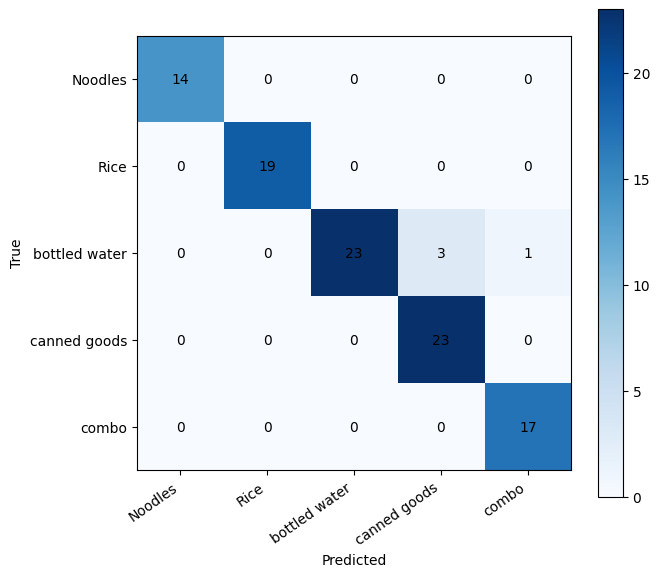

In [18]:

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASS_ORDER)), labels=CLASS_ORDER, rotation=35, ha='right')
ax.set_yticks(range(len(CLASS_ORDER)), labels=CLASS_ORDER)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
for i in range(len(CLASS_ORDER)):
    for j in range(len(CLASS_ORDER)):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'lab10_test_confusion_matrix.png', dpi=180)
plt.show()


## Build Deployment Package

This writes the class labels, preprocessing contract, model card, and sample input. TFLite conversion is included but requires TensorFlow/ONNX tooling in the active environment.

In [19]:

(DEPLOYMENT_DIR / 'labels.txt').write_text('\n'.join(CLASS_ORDER) + '\n', encoding='utf-8')
(DEPLOYMENT_DIR / 'preprocessing.txt').write_text(
    f'Input size: {IMG_SIZE}x{IMG_SIZE} RGB\n'
    f'Input tensor for PyTorch training: NCHW float32, shape (1, 3, {IMG_SIZE}, {IMG_SIZE})\n'
    f'Input tensor for converted TFLite model: NHWC float32, shape (1, {IMG_SIZE}, {IMG_SIZE}, 3) unless converter reports otherwise\n'
    'Resize: center-crop square then resize with area/PIL-style interpolation\n'
    'Color order: RGB\n'
    'Scale: uint8 pixels to [0, 1]\n'
    'Normalization mean: [0.485, 0.456, 0.406]\n'
    'Normalization std: [0.229, 0.224, 0.225]\n',
    encoding='utf-8',
)

sample_source = Path(base_dataset.samples[TEST_INDICES[0]][0])
Image.open(sample_source).convert('RGB').save(DEPLOYMENT_DIR / 'sample_input.jpg')

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
model_card_lines = [
    '# Lab 10 MobileNetV3-small Model Card', '',
    'Source model: GPU retrained PyTorch MobileNetV3-small', '',
    'Dataset: Lab04 EDA Bias Dataset copied from Lab 8; no new Pi-camera training images were collected.', '',
    'Task type: 5-class image classification', '',
    'Classes: ' + ', '.join(CLASS_ORDER), '',
    f'Input shape: RGB {IMG_SIZE}x{IMG_SIZE}, normalized with ImageNet mean/std', '',
    'Output format: logits over 5 classes in labels.txt order', '',
    'Selection rule: best validation macro F1 plus worst-class recall score', '',
    f'Test accuracy: {acc:.4f}', '',
    f'Macro F1: {macro_f1:.4f}', '',
    'Deployment note: run TFLite conversion below before replacing model.tflite on the Raspberry Pi.',
]
(DEPLOYMENT_DIR / 'model_card.md').write_text('\n'.join(model_card_lines) + '\n', encoding='utf-8')
print('Wrote labels, preprocessing contract, model card, and sample input to', DEPLOYMENT_DIR)


Wrote labels, preprocessing contract, model card, and sample input to c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab10_rpi_deployment\deployment_package


In [20]:

# Optional conversion cell. Run after installing tensorflow, onnx, and onnx2tf if they are not already present.
ONNX_PATH = DEPLOYMENT_DIR / 'lab10_mobilenetv3_small.onnx'
TFLITE_PATH = DEPLOYMENT_DIR / 'model.tflite'

dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
model.eval()
torch.onnx.export(
    model, dummy, ONNX_PATH, export_params=True, opset_version=17, do_constant_folding=True,
    input_names=['input'], output_names=['logits'], dynamic_axes=None,
)
print('Wrote ONNX:', ONNX_PATH)

try:
    import tensorflow as tf
    import onnx2tf  # noqa: F401
    saved_model_dir = DEPLOYMENT_DIR / 'saved_model_lab10'
    cmd = [sys.executable, '-m', 'onnx2tf', '-i', str(ONNX_PATH), '-o', str(saved_model_dir), '-n']
    result = subprocess.run(cmd, text=True, capture_output=True)
    (LOGS_DIR / 'lab10_onnx2tf.log').write_text(result.stdout + '\n' + result.stderr, encoding='utf-8')
    if result.returncode != 0:
        raise RuntimeError('onnx2tf conversion failed; inspect outputs/logs/lab10_onnx2tf.log')
    converter = tf.lite.TFLiteConverter.from_saved_model(str(saved_model_dir))
    converter.inference_input_type = tf.float32
    converter.inference_output_type = tf.float32
    TFLITE_PATH.write_bytes(converter.convert())
    print('Wrote TFLite:', TFLITE_PATH)
except ImportError as exc:
    print('Skipping TFLite conversion because TensorFlow/onnx2tf is not installed:', exc)


Wrote ONNX: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab10_rpi_deployment\deployment_package\lab10_mobilenetv3_small.onnx

[TensorFlow DLL Diagnostic] Analyzing: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\.venv\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.
Skipping TFLite conversion because TensorFlow/onnx2tf is not installed: Traceback (most recent call last):
  File "c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\.venv\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 74, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_intern

## Raspberry Pi Next Steps

Copy `deployment_package/` and `scripts/inference_app.py` to the Pi. Run the sample-image sanity check first, then test one live capture per class plus one challenging case. Fill `docs/lab10_report_draft.md` with the measured Pi latency and LED outcomes.